In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("data.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


error: externally-managed-environment

× This environment is externally managed
╰─> This Python installation is managed by uv and should not be modified.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


In [5]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


error: externally-managed-environment

× This environment is externally managed
╰─> This Python installation is managed by uv and should not be modified.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


In [23]:
column_names = [
    "id",
    "diagnosis",
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean"
]

df = pd.read_csv(
    "data.csv",
    sep=r"\s+",
    skiprows=1,
    names=column_names
)

print(df.head())
print(df.shape)

         id diagnosis radius_mean texture_mean perimeter_mean area_mean
0    842302         M       17.99        10.38          122.8      1001
1    842517         M       20.57        17.77          132.9      1326
2  84300903         M       19.69        21.25            130      1203
3  84348301         M       11.42        20.38          77.58     386.1
4  84358402         M       20.29        14.34          135.1      1297
(3419, 6)


In [10]:
print(df.shape)

(3419, 6)


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3419 entries, 0 to 3418
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              3419 non-null   str  
 1   diagnosis       3419 non-null   str  
 2   radius_mean     2849 non-null   str  
 3   texture_mean    2849 non-null   str  
 4   perimeter_mean  2849 non-null   str  
 5   area_mean       2848 non-null   str  
dtypes: str(6)
memory usage: 160.4 KB


print(df.shape)

In [12]:
df.isnull().sum()

id                  0
diagnosis           0
radius_mean       570
texture_mean      570
perimeter_mean    570
area_mean         571
dtype: int64

In [24]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["diagnosis"] = encoder.fit_transform(df["diagnosis"])

In [15]:
df.describe()

,diagnosis
count,3419.000000
mean,1503.122258
std,835.473654
min,0.000000
25%,783.500000
50%,1530.000000
75%,2321.500000
max,2596.000000


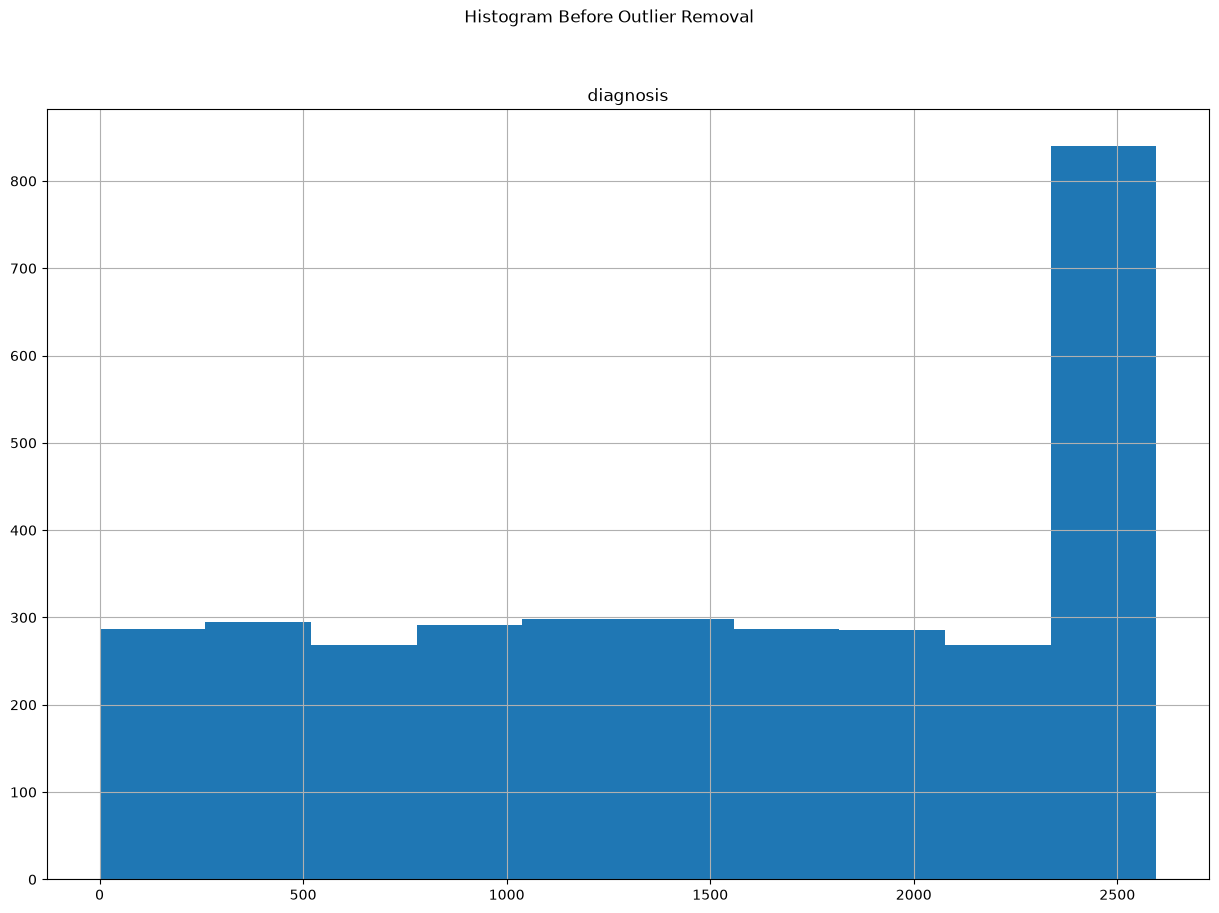

In [16]:
df.hist(figsize=(15,10))

plt.suptitle("Histogram Before Outlier Removal")

plt.show()

In [26]:
print(df.dtypes)

id                  str
diagnosis         int64
radius_mean         str
texture_mean        str
perimeter_mean      str
area_mean           str
dtype: object


In [18]:
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

         id  diagnosis radius_mean texture_mean perimeter_mean area_mean
0    842302       2592       17.99        10.38          122.8      1001
1    842517       2592       20.57        17.77          132.9      1326
2  84300903       2592       19.69        21.25            130      1203
3  84348301       2592       11.42        20.38          77.58     386.1
4  84358402       2592       20.29        14.34          135.1      1297

Columns:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']


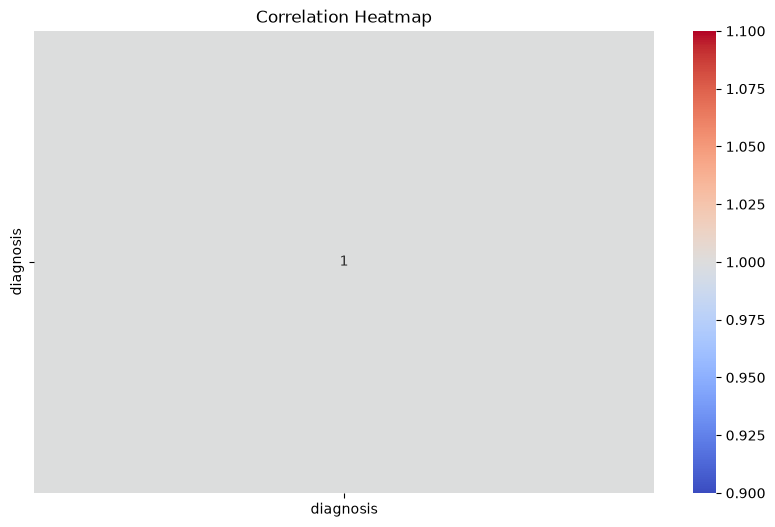

In [27]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

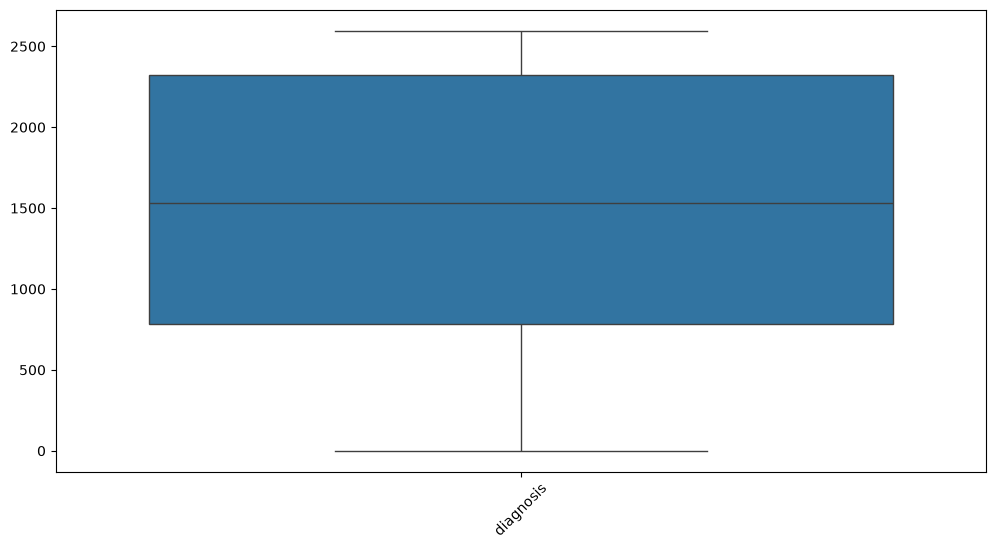

In [29]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.show()

In [30]:
df = df.dropna()

print("Missing Values Removed")
print("Current Shape:", df.shape)

Missing Values Removed
Current Shape: (2848, 6)


In [32]:
df_numeric = df.select_dtypes(include='number')

Q1 = df_numeric.quantile(0.25)

Q3 = df_numeric.quantile(0.75)

IQR = Q3 - Q1

print("IQR Calculated Successfully")

IQR Calculated Successfully


In [33]:
lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

print("Bounds Created Successfully")

Bounds Created Successfully


In [34]:
df_clean = df_numeric[
    ~((df_numeric < lower_bound) |
      (df_numeric > upper_bound)).any(axis=1)
]

print("Original Shape :", df_numeric.shape)

print("After Outlier Removal :", df_clean.shape)

Original Shape : (2848, 1)
After Outlier Removal : (2848, 1)


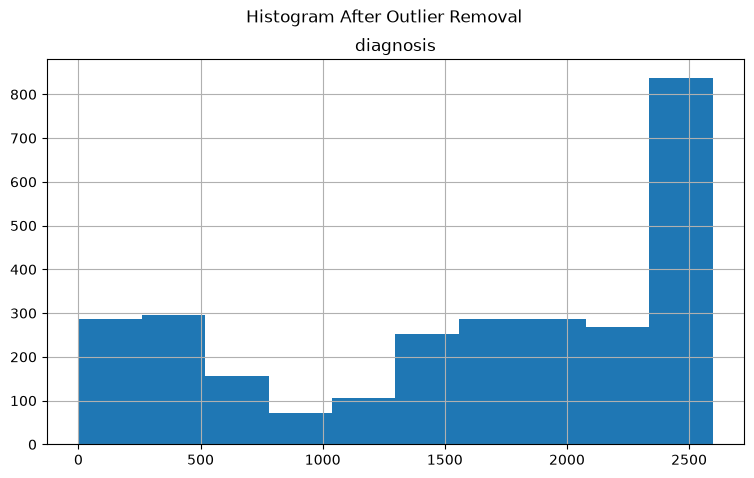

In [42]:
import matplotlib.pyplot as plt

df_clean.hist(figsize=(9,5))

plt.suptitle("Histogram After Outlier Removal")

plt.show()

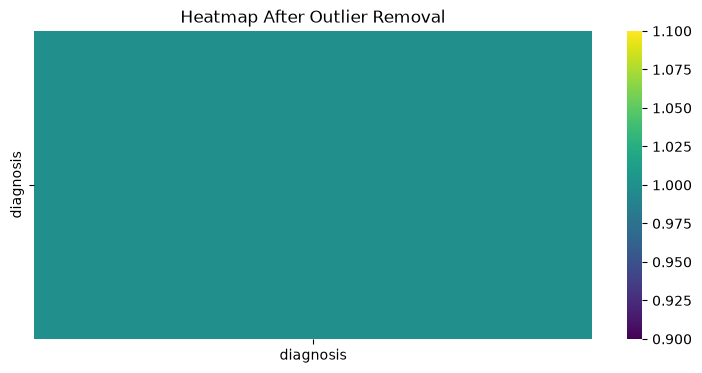

In [43]:
import seaborn as sns

plt.figure(figsize=(9,4))

sns.heatmap(
    df_clean.corr(),
    cmap="viridis"
)

plt.title("Heatmap After Outlier Removal")

plt.show()

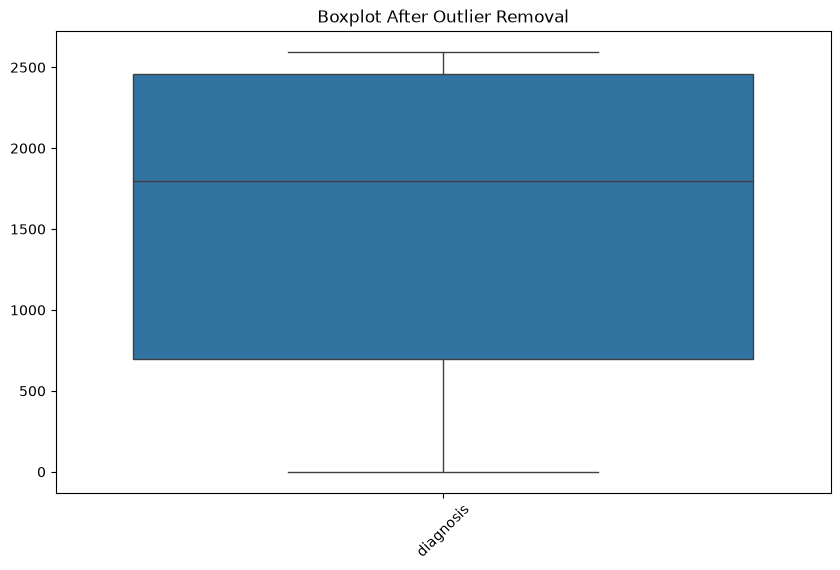

In [46]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df_clean)

plt.xticks(rotation=45)

plt.title("Boxplot After Outlier Removal")

plt.show()

In [47]:
print("Final Clean Dataset")

df_clean.head()

Final Clean Dataset


,diagnosis
0,2592
1,2592
2,2592
3,2592
4,2592
